### Part A - Data Loading and Preprocessing with Scikit-learn

#### Task 1 - Load and Understand the Dataset:

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder


df = pd.read_csv("hotel_bookings.csv")

print("Head: ")
print(df.head())
print("\nShape: ")
print(df.shape)
print("\nInfo: ")
print(df.info())
print("\nDescribe: ")
print(df.describe().T)
print("\nDTypes: ")
print(df.dtypes)

print("\n Target Class Distribution (is_canceled): ")
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])



Head: 
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   

#### Task 2 - Missing Values, Leakage, and Outliers:

In [28]:
missing_count = X.isnull().sum()
missing_percent = (missing_count / len(X)) * 100
missing_df = pd.DataFrame({'Missing Count' : missing_count, 'Missing_Percentage (%)' : missing_percent})
print("\nMissing Value Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

cols_to_drop = ['company', 'reservation_status', 'reservation_status_date']
cols_to_drop = [col for col in cols_to_drop if col in X.columns]

X = X.drop(columns=cols_to_drop)
print(f"\nDropped columns due to high missingness or targer leakage: {cols_to_drop}")

initial_row_count = len(X)

valid_rows = (
    (X['adr'] >= 0) & (X['adr'] < 5000) &
    (X['adults'] > 0) &
    (X['adults'] <= 10)
)

X = X[valid_rows]
y = y[valid_rows]

rows_removed = initial_row_count - len(X)
print(f"Rows removed fue to extreme outliers: {rows_removed} ({rows_removed / initial_row_count * 100:.2f}%) ")

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")


Missing Value Analysis:
          Missing Count  Missing_Percentage (%)
children              4                0.003350
country             488                0.408744
agent             16340               13.686238
company          112593               94.306893

Dropped columns due to high missingness or targer leakage: ['company', 'reservation_status', 'reservation_status_date']
Rows removed fue to extreme outliers: 417 (0.35%) 

Numerical Columns (18): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical Columns (10): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 

C:\Users\choks\AppData\Local\Temp\ipykernel_26660\630262594.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


#### Task 3 - Create Two Preprocessing Pipelines:

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor_A = ColumnTransformer(
    transformers=[
        ('num', num_transformer_A, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_B = ColumnTransformer(
    transformers=[
        ('num', num_transformer_B, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print("\nPipelines Created Successfully")
print("Pipeline A: KNNImputer + StandardScaler")
print("Pipeline B: KNNImputer + MinMacScaler")




Pipelines Created Successfully
Pipeline A: KNNImputer + StandardScaler
Pipeline B: KNNImputer + MinMacScaler


### Part B - Model Training and Performance Evaluation

#### Task 4 - Train Two Classification Models:

In [30]:
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

pipelines = {
    "Logistic Regression (Pipeline A - Standard)": Pipeline([('prep', preprocessor_A), ('clf', lr_model)]),
    "Logistic Regression (Pipeline B - MinMax)":   Pipeline([('prep', preprocessor_B), ('clf', lr_model)]),
    "Decision Tree (Pipeline A - Standard)":      Pipeline([('prep', preprocessor_A), ('clf', dt_model)]),
    "Decision Tree (Pipeline B - MinMax)":        Pipeline([('prep', preprocessor_B), ('clf', dt_model)]),
}

#### Task 5 - Evaluate and Compare the Four Results:

--- FINAL COMPARISON TABLE ---
                           Model & Pipeline  Train Accuracy  test Accuracy  Precision  Recall  F1-Score  Overfit Gap (Train - Test)
Logistic Regression (Pipeline A - Standard)          0.8187         0.8182     0.8126  0.6625    0.7299                      0.0004
  Logistic Regression (Pipeline B - MinMax)          0.8151         0.8152     0.8117  0.6529    0.7237                     -0.0000
      Decision Tree (Pipeline A - Standard)          0.9962         0.8616     0.8117  0.8159    0.8138                      0.1346
        Decision Tree (Pipeline B - MinMax)          0.9962         0.8611     0.8112  0.8150    0.8131                      0.1351


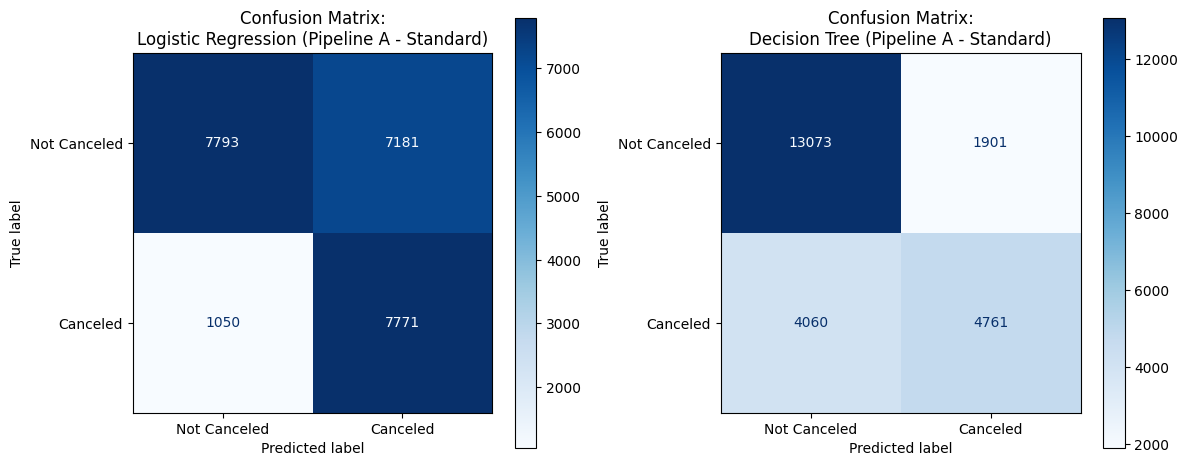

In [31]:
results = []
fitted_pipeline = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipeline[name] = pipe

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        'Model & Pipeline' : name,
        'Train Accuracy' : round(train_acc, 4),
        'test Accuracy' : round(test_acc, 4),
        'Precision' : round(precision, 4),
        'Recall' : round(recall, 4),
        'F1-Score' : round(f1, 4),
        'Overfit Gap (Train - Test)' : round(train_acc - test_acc, 4)
    })

results_df = pd.DataFrame(results)
print("--- FINAL COMPARISON TABLE ---")
print(results_df.to_string(index=False))

best_lr_name = "Logistic Regression (Pipeline A - Standard)"  # Compare metrics to pick best
best_dt_name = "Decision Tree (Pipeline A - Standard)"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, [best_lr_name, best_dt_name]):
    y_pred = fitted_pipeline[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f"Confusion Matrix:\n{name}")

plt.tight_layout()
plt.show()

#### Task 6 - Final Observations:

1. From the above test, it can be seen that decision tree with pipeline A achieves a better overall result than logistic regression. 


2. The standard scaler performs better than the MinMaxScaler in the case of logistic regression. Pipeline A yeilds a higher test accuracy and a higher f1 score because z-score normalization handles variance better than bounding features between [0,1].


3. Scaling has no impact on decision tree model. Both the pipelines A and B produces similar results.


4. Observations supported by the performance table and confusion matrix are as follows: 
   
    a. the Decision tree model overfits significantly, exhibiting a large gap between the training accuracy and the testing accuracy.

    b. Logistic regression shows almost 0 overfitting gap showing excellent generalization.

    c. Logistic regression struggles with recall. It misses a higher percentage of actual hotel cancellations as compared to the decision tree

